# Nested Measurements

In [2]:
%pip install git+https://github.com/bobiac/bobiac-tools.git
%pip install matplotlib
%pip install numpy
%pip install scikit-image
%pip install scipy
%pip install tifffile
%pip install imagecodecs
%pip install pandas
%pip install seaborn

## Overview
In this notebook, we will address a common task in image analysis: **Relating measurements of nested objects**, I.e., measuring objects that are contained within larger scale objects and connecting those. For example, measuring the expression of a nuclear marker and relating that to cell size.

Here, we have cells that express two markers:
* A nuclear marker that is either on or off depending on cell state.
* A marker in the cytoplasm that exhibits spots.
Our question is: **Do cells that are in the nuclear *on* state exhibit more spots in the cytoplasm?**

To answer this question we will:
* Load images and masks (for cells, nuclei and spots (spots are stored in a list of coordinates))
* Use the nuclear masks to classify nuclei as *on* or *off*
* Relate this state to the corresponding cell.
* Identify which spots belong to which cells.
* Count the number of spots per cell.
* Set up a batch processing loop for all fields of view.
* Plot results and draw conclusions.

We will not be introducing new tools and will focus on using the tools we learned in the previous notebook.

The data (images, labeled masks, and spot tables) can be downloaded [here](https://github.com/bobiac/bobiac-book/releases/download/data-bobiac-2026/group-work-1.zip).

## Import libraries

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels

## Load one image and masks
First, we load one image and the corresponding label masks of the cells, nuclei, and spots.

Note that the image is a multi-channel image, therefore we will need to extract the channels that we are interested in. In this case, we are interested in the nuclear channel and the spots channel.

As before, we run through the whole analysis pipeline on this small dataset before we set up batch processing in the end.

In [4]:
# define file paths
image_path = Path(
    "https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/02_nested_measurements/images/F01_837.tif"
)
mask_cell_path = Path(
    "https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/02_nested_measurements/masks/F01_837_cell_labels.tif"
)
mask_nucleus_path = Path(
    "https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/02_nested_measurements/masks/F01_837_nuclei_labels.tif"
)
segmentation_spots_path = Path(
    "https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/02_nested_measurements/spot_lists/F01_837_points.csv"
)

# load images and masks
image = tifffile.imread(image_path)
image_nuclear = image[2]
image_spots = image[3]

mask_cell = tifffile.imread(mask_cell_path)
mask_nucleus = tifffile.imread(mask_nucleus_path)

# remove boundary objects
mask_cell = skimage.segmentation.clear_border(mask_cell)
mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

# load segmented spots
df_spots = pd.read_csv(segmentation_spots_path)

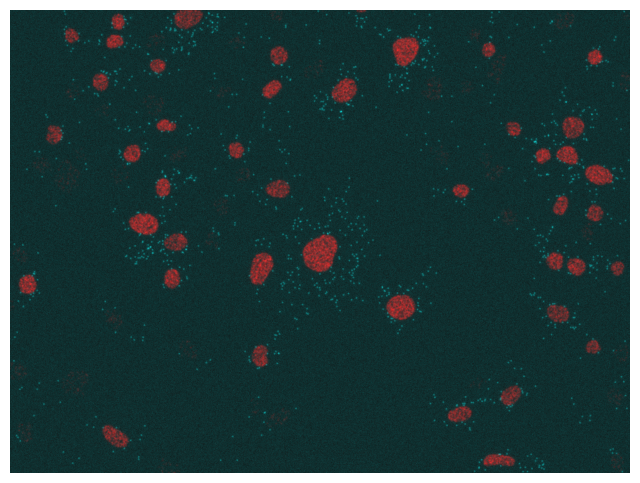

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
overlay_labels(image=[image_nuclear, image_spots])

In [7]:
df_spots = df_spots.rename({'axis-0':'channel', 'axis-1':'y','axis-2':'x'},axis=1)
print(df_spots)

      index  channel            y            x
0         0      3.0  1036.608593  1374.287858
1         1      3.0  1036.347551  1161.474318
2         2      3.0  1036.123795  1151.153616
3         3      3.0  1035.210651  1042.966998
4         4      3.0  1032.543429  1066.596425
...     ...      ...          ...          ...
1156   1156      3.0     6.300192   445.306930
1157   1157      3.0     4.574181  1097.516912
1158   1158      3.0     3.412835  1378.409558
1159   1159      3.0     2.265379   691.332179
1160   1160      3.0     2.470842   121.888725

[1161 rows x 4 columns]


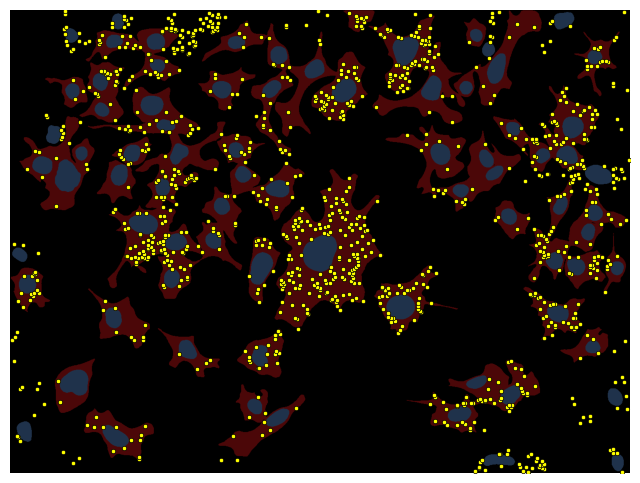

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
overlay_labels(
    label_mask=[mask_cell, mask_nucleus], coordinates=df_spots[["y", "x"]].to_numpy()
)

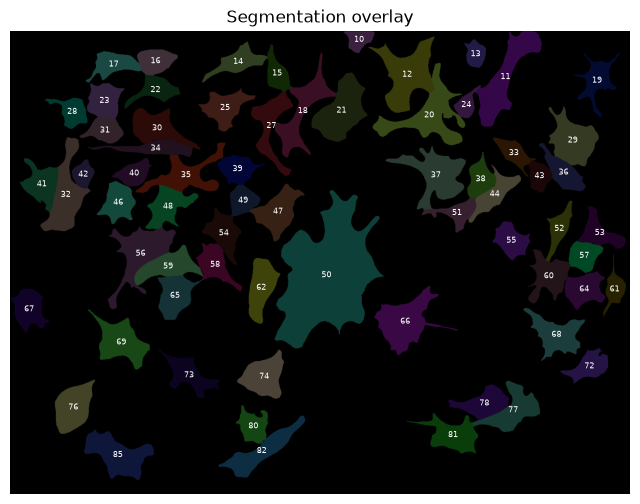

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [9]:
overlay_labels(label_mask=mask_cell)

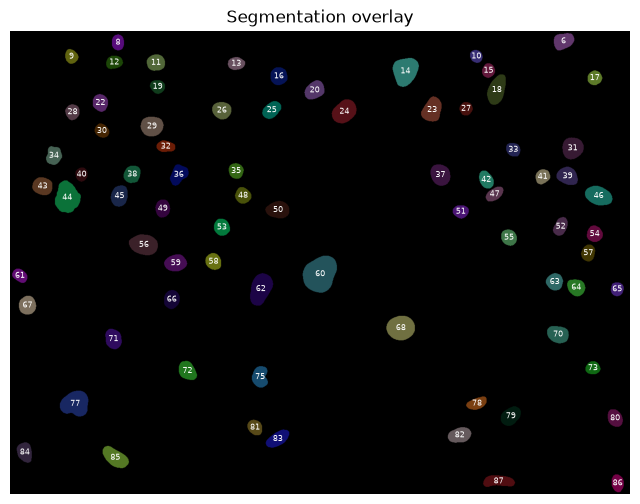

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [13]:
overlay_labels(label_mask=mask_nucleus, alpha=.5)

## Create DataFrame for cells
First, we generate a dataframe that contains all cells. We do this using the `regionprops_table` function.

In [14]:
properties = ["area", "label"]
props = skimage.measure.regionprops_table(mask_cell, properties=properties)

df_cell = pd.DataFrame(props)
print(df_cell)

       area  label
0    2139.0     10
1   10940.0     11
2   11639.0     12
3    2148.0     13
4    4373.0     14
..      ...    ...
62   5359.0     78
63   3809.0     80
64   6289.0     81
65   7052.0     82
66   8976.0     85

[67 rows x 2 columns]


That was simple. This table now contains all labels of the cells.

## Classify nuclei
Now, we classify the each nucleus' expression levels of the nuclear marker into *on* and *off*.
For that we use the label mask of the nuclei, the nuclear expression image and the `regionpros_table` function.

### Measure properties

In [15]:
properties = ["area", "intensity_mean", "label"]
props = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=image_nuclear, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1377.0      411.344227      6
1    796.0     1914.856784      8
2    744.0     1612.961022      9
3    643.0      420.241058     10
4   1222.0      354.035188     11
..     ...             ...    ...
72  1371.0      393.645514     83
73  1216.0      404.171875     84
74  1868.0     1580.623126     85
75   866.0      422.398383     86
76  1471.0     1869.467029     87

[77 rows x 3 columns]


Let's add an `image_id` for book keeping.

In [16]:
df_nuc["image_id"] = image_path.stem
print(df_nuc)

      area  intensity_mean  label image_id
0   1377.0      411.344227      6  F01_837
1    796.0     1914.856784      8  F01_837
2    744.0     1612.961022      9  F01_837
3    643.0      420.241058     10  F01_837
4   1222.0      354.035188     11  F01_837
..     ...             ...    ...      ...
72  1371.0      393.645514     83  F01_837
73  1216.0      404.171875     84  F01_837
74  1868.0     1580.623126     85  F01_837
75   866.0      422.398383     86  F01_837
76  1471.0     1869.467029     87  F01_837

[77 rows x 4 columns]


### Classify by intensity
To understand where we should set our threshold for *on* / *off*, we can plot the intensity measurements as a histogram.

<Axes: xlabel='intensity_mean', ylabel='Count'>

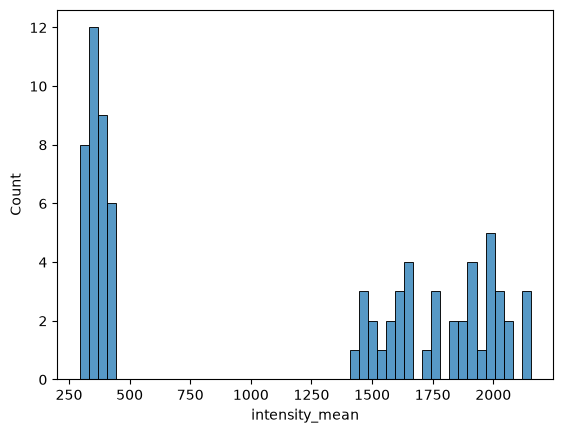

In [17]:
sns.histplot(
    data=df_nuc,
    x="intensity_mean",
    bins=50,
)

It seems like the expression is truly bimodal and 1,000 would be a good threshold. 

Now, we classify the intensity of nuclei using the `cut` function as before.

In [18]:
df_nuc["expression"] = pd.cut(
    df_nuc["intensity_mean"], bins=[0, 1000, np.inf], labels=["off", "on"]
)
print(df_nuc["expression"].unique())

['off', 'on']
Categories (2, str): ['off' < 'on']


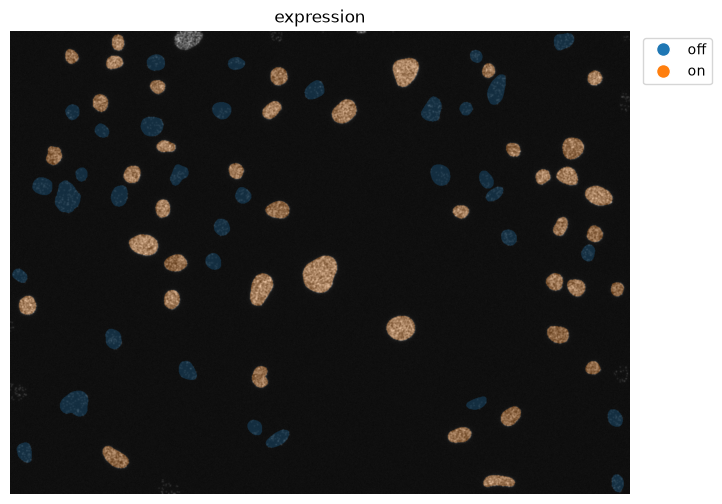

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [19]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_nucleus,
    df=df_nuc,
    id_col="label",
    measurement_col="expression",
)

In [20]:
print(df_nuc)

      area  intensity_mean  label image_id expression
0   1377.0      411.344227      6  F01_837        off
1    796.0     1914.856784      8  F01_837         on
2    744.0     1612.961022      9  F01_837         on
3    643.0      420.241058     10  F01_837        off
4   1222.0      354.035188     11  F01_837        off
..     ...             ...    ...      ...        ...
72  1371.0      393.645514     83  F01_837        off
73  1216.0      404.171875     84  F01_837        off
74  1868.0     1580.623126     85  F01_837         on
75   866.0      422.398383     86  F01_837        off
76  1471.0     1869.467029     87  F01_837         on

[77 rows x 5 columns]


Great! Now we have a DataFrame where each nucleus is classified as expressing or non-expressing.

## Connecting the DataFrames
We now have three DataFrames:
* `df_cell` stores information about the cells, like their area and label
* `df_nuc` stores information about the nuclei, including the expression status
* `df_spots` stores the coordinates of the spots

We want to connect information about the nucleus (*on*/*off*) with information about the spots (how many/per cell). Both of these are properties of the cell, which makes it our central object. Another way of looking at this is that the cell is the unifying object that contains both the nucleus (and its expression state) and all the dots. Dots and nuclei are not directly connected.

Practically, this means we need to create two columns in `df_cell`:
* `nuclear_expression`: that maps the expression classification of the nucleus to the cell
* `number_of_spots`: that contains how many spots exist in each cell

### Map nuclear expression
To map the expression of the nuclei to the cells, we need to know which nuclear label corresponds to which cell label. As we can see below, they are not identical.

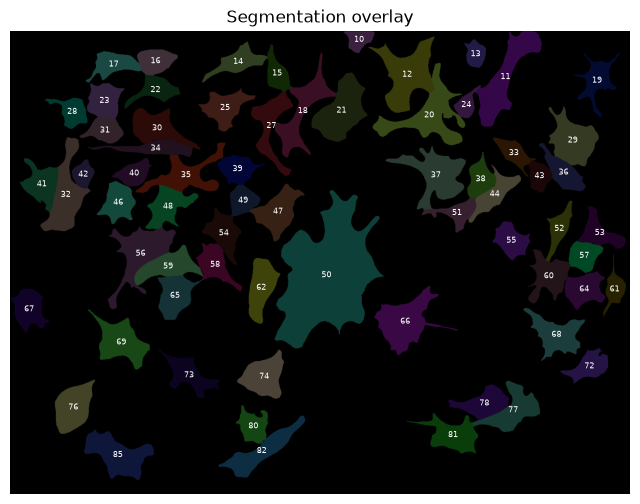

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [21]:
overlay_labels(label_mask=mask_cell)

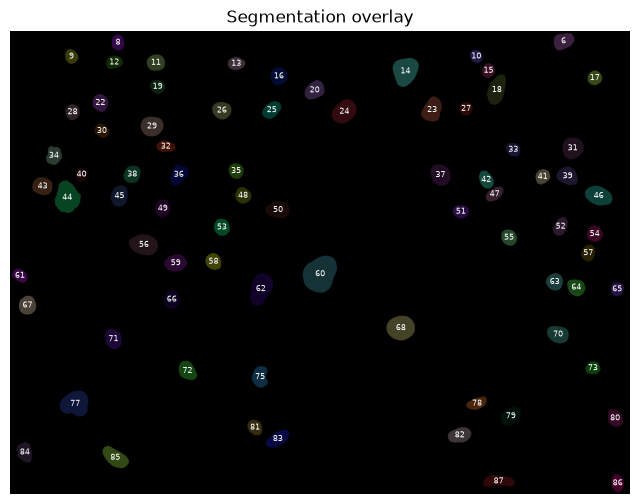

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [22]:
overlay_labels(label_mask=mask_nucleus)

We can use regionprops_table to measure identify the cell label of each nucleus.

In [23]:
properties = ["intensity_mean", "label"]
labels = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=mask_cell, properties=properties
)

df_merge = pd.DataFrame(labels)
df_merge = df_merge.rename({"intensity_mean": "label_cell"}, axis=1)
print(df_merge)

    label_cell  label
0          0.0      6
1          0.0      8
2          0.0      9
3         13.0     10
4         16.0     11
..         ...    ...
72        82.0     83
73         0.0     84
74        85.0     85
75         0.0     86
76         0.0     87

[77 rows x 2 columns]


In [24]:
df_nuc = df_nuc.merge(df_merge, on="label", how="left")
print(df_nuc)

      area  intensity_mean  label image_id expression  label_cell
0   1377.0      411.344227      6  F01_837        off         0.0
1    796.0     1914.856784      8  F01_837         on         0.0
2    744.0     1612.961022      9  F01_837         on         0.0
3    643.0      420.241058     10  F01_837        off        13.0
4   1222.0      354.035188     11  F01_837        off        16.0
..     ...             ...    ...      ...        ...         ...
72  1371.0      393.645514     83  F01_837        off        82.0
73  1216.0      404.171875     84  F01_837        off         0.0
74  1868.0     1580.623126     85  F01_837         on        85.0
75   866.0      422.398383     86  F01_837        off         0.0
76  1471.0     1869.467029     87  F01_837         on         0.0

[77 rows x 6 columns]


In [25]:
mapping = df_nuc.loc[df_nuc["label_cell"] != 0].drop_duplicates(
    "label_cell", keep=False
)[["label_cell", "expression"]]
mapping

,label_cell,expression
3,13.0,off
4,16.0,off
5,17.0,on
6,14.0,off
7,12.0,on
...,...,...
68,77.0,on
70,80.0,off
71,81.0,on
72,82.0,off


In [26]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression
0   10940.0     11        off
1   11639.0     12         on
2    2148.0     13        off
3    4373.0     14        off
4    3178.0     15         on
..      ...    ...        ...
61   5359.0     78        off
62   3809.0     80        off
63   6289.0     81         on
64   7052.0     82        off
65   8976.0     85         on

[66 rows x 3 columns]


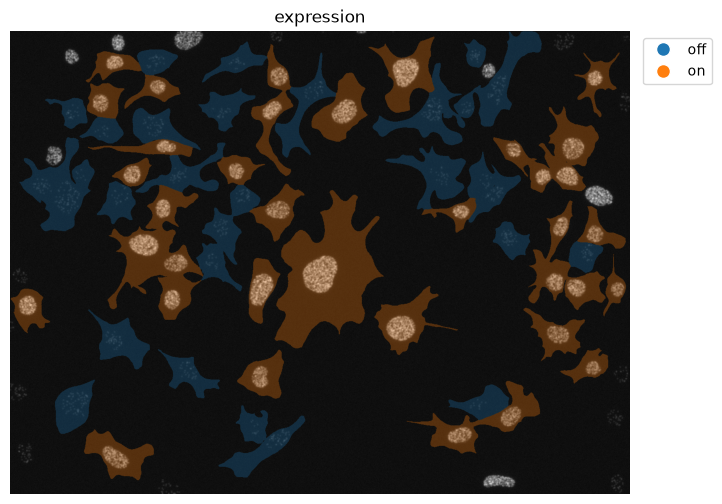

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

In [27]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="expression",
)

### Map spot count
Now we applyt the same strategy to map the number of spots to `df_cell`. 
* Per spot, identify which cell it belongs to
* Count the number of spots per cell
* Add that information to the cell dataframe

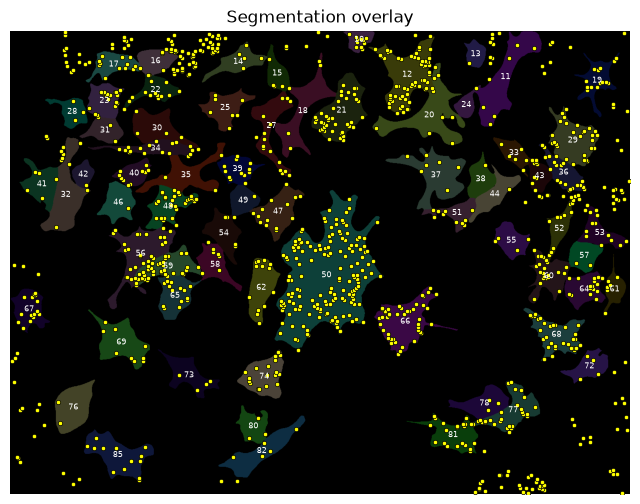

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [28]:
overlay_labels(label_mask=mask_cell, coordinates=df_spots[["y", "x"]].to_numpy())

For each spot in `df_spots` we look up the cell label in `mask_cell`. 

In [29]:
df_spots["label_cell"] = mask_cell[df_spots["y"].astype(int), df_spots["x"].astype(int)]
print(df_spots["label_cell"].unique())

[ 0 85 82 81 80 77 76 78 73 74 72 69 68 66 50 67 62 61 65 60 64 59 56 58
 57 52 55 54 53 47 32 51 48 49 46 41 36 35 43 37 44 40 42 39 27 33 38 29
 34 30 18 20 31 21 25 11 28 23 12 22 19 24 15 17 16 14 13 10]


Now we count the number of spots per `cell_label`.

<Axes: xlabel='label_cell', ylabel='Count'>

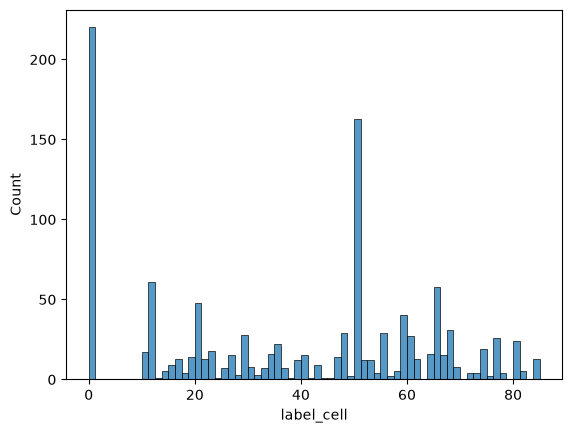

In [30]:
sns.histplot(data=df_spots, x="label_cell", bins=len(df_spots["label_cell"].unique()))

Remove spots with `cell_label == 0`. Those spots are outside of valid cells.

In [31]:
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
print(df_spots)

      index  channel            y           x  label_cell
25       25      3.0  1008.142417  288.266766          85
28       28      3.0  1003.216643  288.663090          85
37       37      3.0   991.103402  231.628243          85
41       41      3.0   984.213412  256.187646          85
43       43      3.0   966.446207  270.281314          85
...     ...      ...          ...         ...         ...
1135   1135      3.0    18.652871  787.231528          10
1136   1136      3.0    18.447809  779.565676          10
1142   1142      3.0    16.098957  799.597937          10
1146   1146      3.0    12.406795  776.313067          10
1154   1154      3.0     6.637079  760.532552          10

[941 rows x 5 columns]


Now we count the spots per cell, I.e., per unique `label_cell`.

In [32]:
mapping = df_spots["label_cell"].value_counts().reset_index()
print(mapping)

    label_cell  count
0           50    153
1           12     61
2           66     44
3           21     41
4           59     40
..         ...    ...
62          44      1
63          42      1
64          38      1
65          24      1
66          13      1

[67 rows x 2 columns]


Now we merge these measurements with `df_cell`.

In [33]:
df_cell = df_cell.merge(
    mapping, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_cell)

       area  label expression  count
0   10940.0     11        off      6
1   11639.0     12         on     61
2    2148.0     13        off      1
3    4373.0     14        off      5
4    3178.0     15         on      5
..      ...    ...        ...    ...
61   5359.0     78        off      4
62   3809.0     80        off      3
63   6289.0     81         on     21
64   7052.0     82        off      5
65   8976.0     85         on     13

[66 rows x 4 columns]


<Axes: xlabel='count', ylabel='Count'>

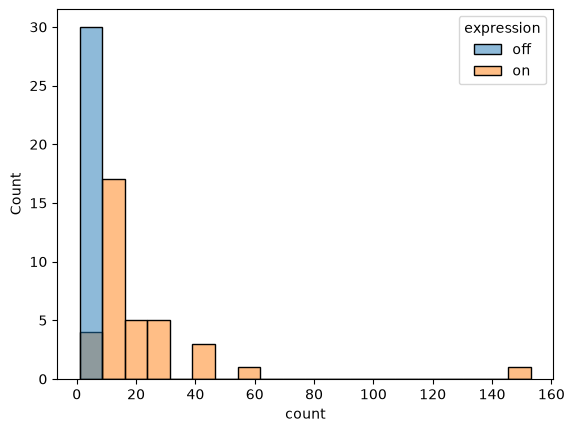

In [34]:
sns.histplot(
    data=df_cell,
    x="count",
    bins=20,
    hue="expression",
)

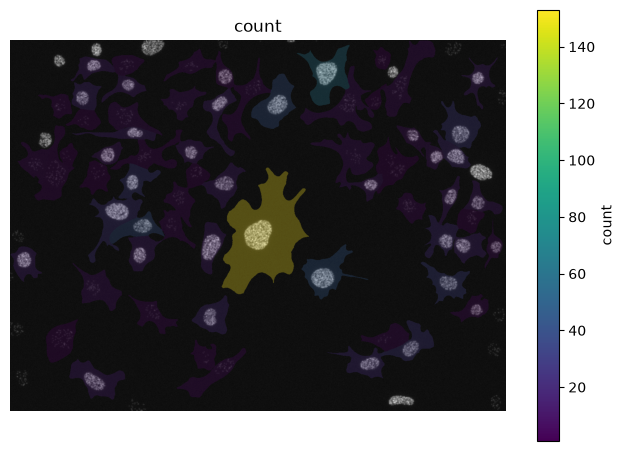

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [35]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="count",
)

## Normalisation
We can see from the overlay above that the largest cell also has the most spots. This might be a case of size and number of spots being confunding variables; larger cells have more space and therefore more spots. Let's normalise the spot count by area.

In [36]:
df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]
print(df_cell["spot_count_norm"])

0     0.000548
1     0.005241
2     0.000466
3     0.001143
4     0.001573
        ...   
61    0.000746
62    0.000788
63    0.003339
64    0.000709
65    0.001448
Name: spot_count_norm, Length: 66, dtype: float64


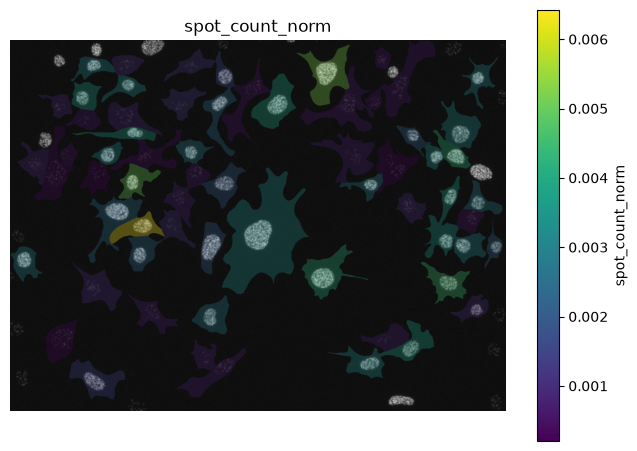

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'spot_count_norm'}>)

In [37]:
overlay_labels(
    image=image_nuclear,
    label_mask=mask_cell,
    df=df_cell,
    id_col="label",
    measurement_col="spot_count_norm",
)

<Axes: xlabel='spot_count_norm', ylabel='Count'>

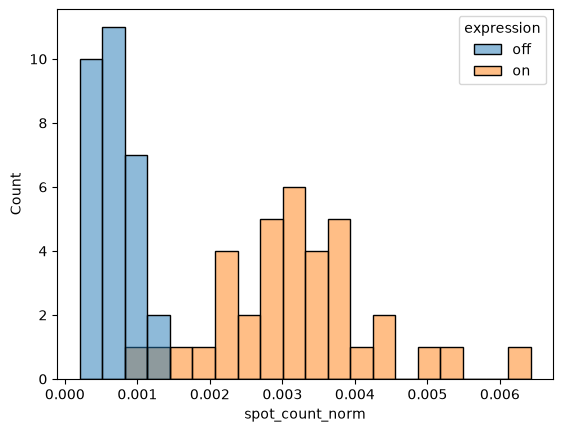

In [38]:
sns.histplot(data=df_cell, x="spot_count_norm", bins=20, hue="expression")

The picture is much clearer now.

## Batch processing
Now we set up batch processing to analyse all the images in the folder.

In [43]:
image_folder = Path("/Users/max/Desktop/bobiac_data/group-work-1/")
cell_mask_folder = Path("/Users/max/Desktop/bobiac_data/group-work-1/solution/cell_labels/")
nuc_mask_folder = Path("/Users/max/Desktop/bobiac_data/group-work-1/solution/nuclei_labels/")
spot_folder = Path("/Users/max/Desktop/bobiac_data/group-work-1/solution/spotiflow_points/")

image_paths = sorted(image_folder.glob("*.tif"))

list_df = []

for image_path in image_paths:
    image_id = image_path.stem  # e.g. F01_837

    # load multi-channel image and extract nuclear channel
    image = tifffile.imread(image_path)
    image_nuclear = image[0]

    # load masks and spot coordinates
    mask_cell = tifffile.imread(cell_mask_folder / f"{image_id}_cell_labels.tif")
    mask_nucleus = tifffile.imread(nuc_mask_folder / f"{image_id}_nuclei_labels.tif")
    df_spots = pd.read_csv(spot_folder / f"{image_id}_points.csv")
    df_spots = df_spots.rename({'axis-0':'channel', 'axis-1':'y','axis-2':'x'},axis=1)

    # remove objects touching the border
    mask_cell = skimage.segmentation.clear_border(mask_cell)
    mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

    # --- cell dataframe ---
    df_cell = pd.DataFrame(
        skimage.measure.regionprops_table(mask_cell, properties=["area", "label"])
    )

    # --- nucleus dataframe: measure and classify expression ---
    df_nuc = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=image_nuclear,
            properties=["area", "intensity_mean", "label"],
        )
    )
    df_nuc["image_id"] = image_id
    df_nuc["expression"] = pd.cut(
        df_nuc["intensity_mean"], bins=[0, 1000, np.inf], labels=["off", "on"]
    )

    # --- map each nucleus to the cell it sits in ---
    df_merge = pd.DataFrame(
        skimage.measure.regionprops_table(
            mask_nucleus,
            intensity_image=mask_cell,
            properties=["intensity_mean", "label"],
        )
    ).rename(columns={"intensity_mean": "label_cell"})

    df_nuc = df_nuc.merge(df_merge, on="label", how="left")

    mapping_expr = df_nuc[df_nuc["label_cell"] != 0].drop_duplicates(
        "label_cell", keep=False
    )[["label_cell", "expression"]]
    df_cell = df_cell.merge(
        mapping_expr, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")

    # --- count spots per cell ---
    df_spots["label_cell"] = mask_cell[
        df_spots["y"].astype(int), df_spots["x"].astype(int)
    ]
    df_spots = df_spots.loc[df_spots["label_cell"] != 0]
    mapping_spots = df_spots["label_cell"].value_counts().reset_index()
    df_cell = df_cell.merge(
        mapping_spots, left_on="label", right_on="label_cell", how="inner"
    ).drop(columns="label_cell")
    df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]

    df_cell["image_id"] = image_id
    list_df.append(df_cell)

df_full = pd.concat(list_df, ignore_index=True)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_68778/79360215.py:59: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell = df_cell.merge(
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_68778/79360215.py:59: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell = df_cell.merge(
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_68778/79360215.py:59: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell = df_cell.merge(
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_68778/79360215.py:59: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell = df_cell.merge(
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_68778/79360215.py:59: UserWar

In [44]:
print(df_full)

       area  label expression  count  spot_count_norm  image_id
0    8853.0      7        off     49         0.005535  F01_1296
1    9373.0      8        off      7         0.000747  F01_1296
2    3181.0      9         on      1         0.000314  F01_1296
3    2032.0     10         on     10         0.004921  F01_1296
4    4630.0     11        off     25         0.005400  F01_1296
..      ...    ...        ...    ...              ...       ...
708  5716.0     82         on     48         0.008397   F01_972
709  2680.0     83         on      4         0.001493   F01_972
710  3589.0     86         on     16         0.004458   F01_972
711  3642.0     89         on     12         0.003295   F01_972
712  3548.0     92         on     18         0.005073   F01_972

[713 rows x 6 columns]


In [45]:
df_plot = (
    df_full.groupby(["expression", "image_id"])[["count", "spot_count_norm"]]
    .mean()
    .reset_index()
)
df_plot

,expression,image_id,count,spot_count_norm
0,off,F01_1296,16.263158,0.002314
1,off,F01_1377,13.272727,0.001640
2,off,F01_1457,21.428571,0.002420
3,off,F01_1464,27.750000,0.002984
4,off,F01_1465,20.714286,0.001492
5,off,F01_1467,24.400000,0.002116
6,off,F01_837,23.000000,0.002225
7,off,F01_840,22.333333,0.001741
8,off,F01_884,11.714286,0.001664
9,off,F01_972,10.750000,0.001451


<Axes: xlabel='expression', ylabel='count'>

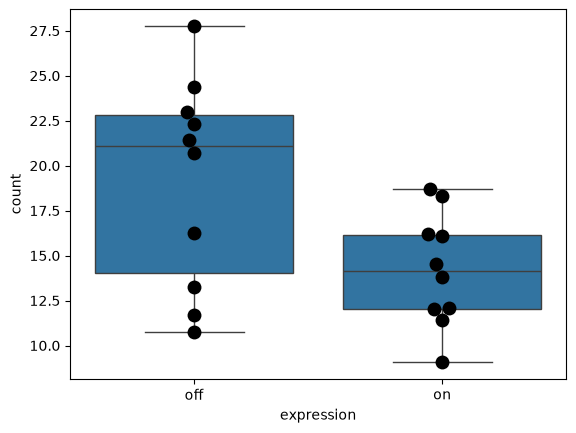

In [49]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="count",
)

sns.swarmplot(data=df_plot, x="expression", y="count", c="k", s=10)


<Axes: xlabel='expression', ylabel='spot_count_norm'>

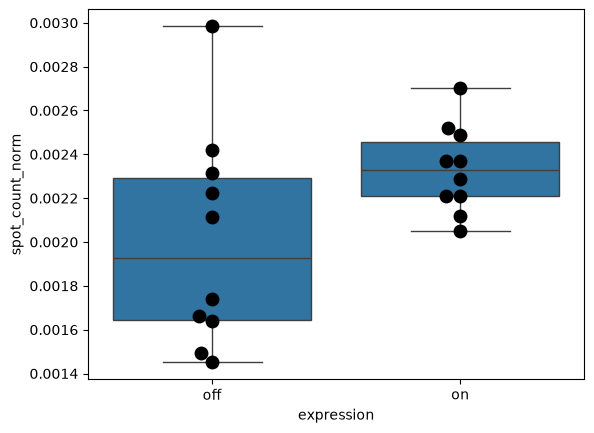

In [48]:
sns.boxplot(
    data=df_plot,
    x="expression",
    y="spot_count_norm",
)

sns.swarmplot(data=df_plot, x="expression", y="spot_count_norm", c="k", s=10)


## Conclusion
We successfully integrated properties of different objects with each other. Handling these sort of nested measurements is a key aspect of analysing images.